In [1]:
# Install the Kaggle CLI API tool
!pip install -q kaggle

# upload your kaggle.json file (which you download from your Kaggle Account Settings)
from google.colab import files
print("Please select your 'kaggle.json' token file:")
uploaded = files.upload()

# Set up kaggle configuration directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
# Change permissions to secret read-only for the owner
!chmod 600 ~/.kaggle/kaggle.json

Please select your 'kaggle.json' token file:


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [2]:
# Download the face-mask-dataset created by Omkar Gurav
import zipfile

print("Extracting dataset...")

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('face_mask_dataset')

print("Dataset extracted successfully!")

Extracting dataset...


FileNotFoundError: [Errno 2] No such file or directory: 'archive.zip'

In [2]:
!pwd

/content


In [3]:
!ls /content

sample_data


In [4]:
!find / -name "archive.zip" 2>/dev/null

/archive.zip


In [7]:
import zipfile

with zipfile.ZipFile('/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/face_mask_dataset')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [8]:
!ls /content/face_mask_dataset

data


In [9]:
!ls /content/face_mask_dataset/data

with_mask  without_mask


In [10]:
# Import required deep-learning and computer vision packages
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

# Define directory roots for our categories
with_mask_dir = '/content/face_mask_dataset/data/with_mask'
without_mask_dir = '/content/face_mask_dataset/data/without_mask'

# Get and print sample logs
with_mask_files = os.listdir(with_mask_dir)
without_mask_files = os.listdir(without_mask_dir)

print(f"Total 'with_mask' images found: {len(with_mask_files)}")
print(f"Total 'without_mask' images found: {len(without_mask_files)}")

Total 'with_mask' images found: 3725
Total 'without_mask' images found: 3828


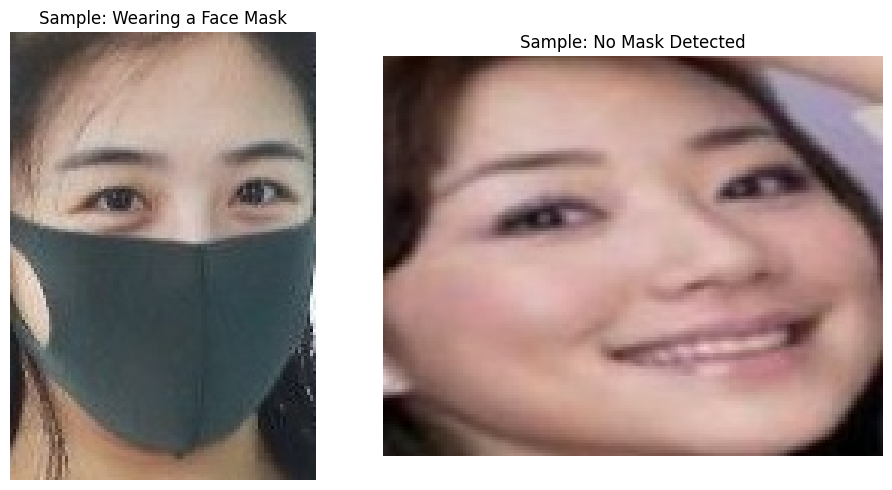

In [11]:
# Load and display random individual samples side-by-side
plt.figure(figsize=(10, 5))

# Plot one sample From WITH MASK directory
plt.subplot(1, 2, 1)
sample_masked = mpimg.imread(os.path.join(with_mask_dir, with_mask_files[0]))
plt.imshow(sample_masked)
plt.title('Sample: Wearing a Face Mask')
plt.axis('off')

# Plot one sample From WITHOUT MASK directory
plt.subplot(1, 2, 2)
sample_unmasked = mpimg.imread(os.path.join(without_mask_dir, without_mask_files[0]))
plt.imshow(sample_unmasked)
plt.title('Sample: No Mask Detected')
plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Create empty lists to store all target feature arrays and labels
data = []
labels = []

# Label Encoding mappings:
# 1 -> Person Wearing a Mask (with_mask)
# 0 -> Person NOT Wearing a Mask (without_mask)

# 1. Read 'with mask' files
for img_name in with_mask_files:
    img_path = os.path.join(with_mask_dir, img_name)
    try:
        # Load from disk
        image = cv2.imread(img_path)
        # Convert standard OpenCV BGR colors to human-standard RGB colors
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        # Resize to standard height-width (128, 128) matching our input shape
        image = cv2.resize(image, (128, 128))
        data.append(image)
        labels.append(1) # Class 1
    except Exception as e:
        # Ignore corrupted or invalid image formats on load
        continue

# 2. Read 'without_mask' files
for img_name in without_mask_files:
    img_path = os.path.join(without_mask_dir, img_name)
    try:
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (128, 128))
        data.append(image)
        labels.append(0) # Class 0
    except Exception as e:
        continue

# Convert our list of images/labels into NumPy arrays for tensor computation
X = np.array(data)
Y = np.array(labels)

print(f"Features Array (X Shape): {X.shape} (Count, Width, Height, Channels)")
print(f"Labels Array (Y Shape): {Y.shape} (Count,)")

Features Array (X Shape): (7553, 128, 128, 3) (Count, Width, Height, Channels)
Labels Array (Y Shape): (7553,) (Count,)


In [13]:
# Split features into 80% training data and 20% test validation data
# 'stratify=Y' guarantees an even balance of classes in both train and test splits
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

# Normalize the RGB pixel integer integers (0-255) to floated points (0.0 - 1.0)
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

print(f"Scaled Training Data Shape: {X_train_scaled.shape}")
print(f"Scaled Testing Data Shape: {X_test_scaled.shape}")

Scaled Training Data Shape: (6042, 128, 128, 3)
Scaled Testing Data Shape: (1511, 128, 128, 3)


In [14]:
# Build a Sequential CNN model utilizing keras
model = keras.Sequential([
    # First Convolutional Block (Extracts edge features like nose, chin, eyes)
    keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(128, 128, 3)),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Second Convolutional Block (Extracts advanced shape combinations)
    keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Third Convolutional Block (Extracts complex face structural features)
    keras.layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten the 3D matrices into a 1D vector of features
    keras.layers.Flatten(),

    # Fully-Connected Dense layer with Dropout regularization
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5), # Regularization shuts down 50% of nodes randomly per batch

    # Second Fully-Connected Layer
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.5),

    # Softmax output layer with 2 logits (Class 0: No Mask, Class 1: Mask)
    keras.layers.Dense(2, activation='softmax')
])

# Print detailed summaries of the parameters and weights
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,313,026 (12.64 MB)

 Trainable params: 3,313,026 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compile model specifying learning parameters
# We use Adam optimizer, Sparse Categorical Crossentropy (since labels are raw integers: 0 or 1)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully and ready for train runs!")

CNN model compiled successfully and ready for train runs!


In [16]:
# Run training on normalized training matrices
# We train for 10 epochs (tweakable), using a batch size of 32
# validation_split=0.1 extracts 10% of train inputs for epoch-by-epoch loss validation
history = model.fit(
    X_train_scaled,
    Y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

print("CNN Model training sequence completed successfully!")

Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.8227 - loss: 0.4120 - val_accuracy: 0.8678 - val_loss: 0.3144
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8816 - loss: 0.3031 - val_accuracy: 0.8727 - val_loss: 0.2824
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8970 - loss: 0.2594 - val_accuracy: 0.8694 - val_loss: 0.2777
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9080 - loss: 0.2296 - val_accuracy: 0.8959 - val_loss: 0.2802
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9226 - loss: 0.2013 - val_accuracy: 0.9025 - val_loss: 0.2362
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9297 - loss: 0.1713 - val_accuracy: 0.9289 - val_loss: 0.2072
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9419 - loss: 0.1493 - val_accuracy: 0.9174 - val_loss: 0.2470
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9397 - loss: 0.1581 - val_acc

In [17]:
# Evaluate accuracy on test images
test_loss, test_acc = model.evaluate(X_test_scaled, Y_test, verbose=1)

print("\n------------------------------------")
print(f"Test Set Loss:     {test_loss:.4f}")
print(f"Test Set Accuracy: {test_acc * 100:.2f}%")
print("------------------------------------")

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9550 - loss: 0.1615

------------------------------------
Test Set Loss:     0.1615
Test Set Accuracy: 95.50%
------------------------------------


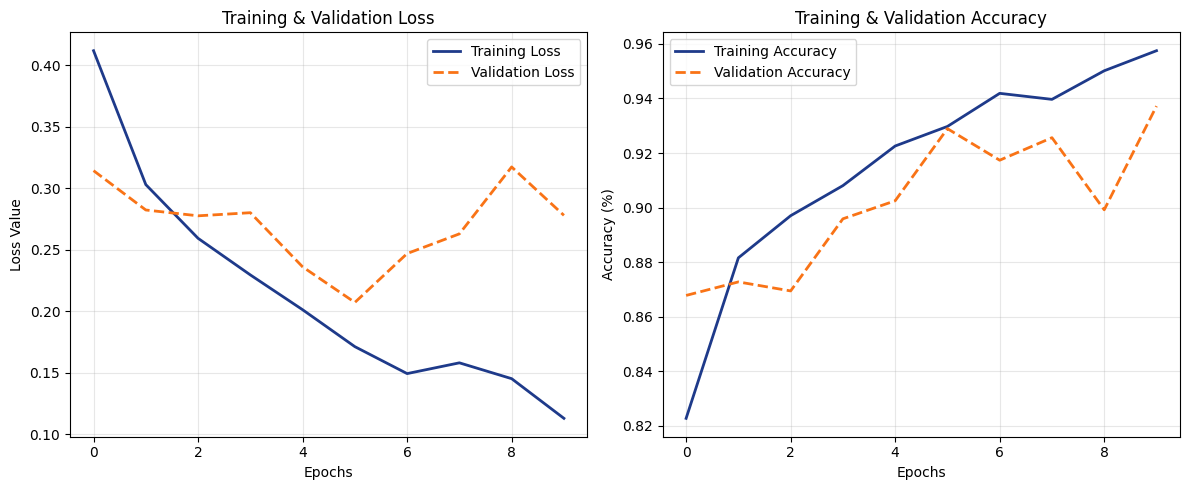

In [18]:
# Extract historic metric values
epoch_history = history.history

plt.figure(figsize=(12, 5))

# Subplot 1: Crossentropy Loss curves
plt.subplot(1, 2, 1)
plt.plot(epoch_history['loss'], label='Training Loss', color='#1e3a8a', linewidth=2)
plt.plot(epoch_history['val_loss'], label='Validation Loss', color='#f97316', linewidth=2, linestyle='--')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Categorical Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(epoch_history['accuracy'], label='Training Accuracy', color='#1e3a8a', linewidth=2)
plt.plot(epoch_history['val_accuracy'], label='Validation Accuracy', color='#f97316', linewidth=2, linestyle='--')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Save the full trained architecture (weights & hyper-configurations) as an H5 file
model.save('mask_detector.h5')
print("Standard package saved: 'mask_detector.h5' is offline and ready for download!")

# Create a robust inference tester function
def test_mask_prediction(image_path):
    # Verify the image exists on path
    if not os.path.exists(image_path):
        print(f"Error: Target path '{image_path}' not found.")
        return

    # Read image and format similarly to CNN input specifications (128, 128)
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))

    # Scale from 0.0 to 1.0
    img_normalized = img_resized / 255.0

    # Reshape matching tensor batch shape mapping (1, 128, 128, 3)
    img_tensor = np.expand_dims(img_normalized, axis=0)

    # Execute class predictions
    probabilities = model.predict(img_tensor)
    predicted_class = np.argmax(probabilities) # 0 for Unmasked, 1 for Masked
    confidence_pct = probabilities[0][predicted_class] * 100

    print("\n================ DETECTION OUTCOME ================")
    if predicted_class == 1:
        print(f"Outcome:   WITH MASK DETECTED")
        print(f"Confidence score: {confidence_pct:.2f}%")
    else:
        print(f"Outcome:   NO MASK DETECTED")
        print(f"Confidence score: {confidence_pct:.2f}%")
    print("====================================================")

# Example usage (Uncomment below to test with your own file upload):
# test_mask_prediction('my_test_photo.jpg')

Standard package saved: 'mask_detector.h5' is offline and ready for download!


In [20]:
!find / -name "mask_detector.h5" 2>/dev/null

/content/mask_detector.h5


In [21]:
from google.colab import files
files.download('/content/mask_detector.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>